In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import glob
import pickle

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})

%matplotlib widget

In [2]:
# Define data folder and figure save folder
data_folder = '../data'
data_folder = os.path.abspath(data_folder)
print(f'Data folder: {data_folder}')

figure_save_folder = '../figures/CKII_pooled'
figure_save_folder = os.path.abspath(figure_save_folder)
os.makedirs(figure_save_folder, exist_ok=True)
print(f'Figures will be saved to: {figure_save_folder}')

speed_threshold = 3

Data folder: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data
Figures will be saved to: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled


In [3]:
# Load theta amplitude data (in/out place field)
pattern = os.path.join(data_folder, 'CKII**', f'theta_amp_speed{speed_threshold}.npz')
npz_files = glob.glob(pattern, recursive=True)
print(f'Found {len(npz_files)} theta_amp files')

theta_run_in_all = []
theta_run_out_all = []
theta_rest_in_all = []
theta_rest_out_all = []

for npz_path in npz_files:
    data = np.load(npz_path)
    theta_run_in_all.append(data['theta_run_in'])
    theta_run_out_all.append(data['theta_run_out'])
    theta_rest_in_all.append(data['theta_rest_in'])
    theta_rest_out_all.append(data['theta_rest_out'])
    print(f'  Loaded {os.path.basename(os.path.dirname(npz_path))}: {len(data["theta_run_in"])} cells')

theta_data = {
    'run_in': np.concatenate(theta_run_in_all) if theta_run_in_all else np.array([]),
    'run_out': np.concatenate(theta_run_out_all) if theta_run_out_all else np.array([]),
    'rest_in': np.concatenate(theta_rest_in_all) if theta_rest_in_all else np.array([]),
    'rest_out': np.concatenate(theta_rest_out_all) if theta_rest_out_all else np.array([]),
}
print(f'Total theta amp cells: {len(theta_data["run_in"])}')

Found 3 theta_amp files
  Loaded CKII_pAce21_PR_20250806: 3 cells
  Loaded CKII_pAce45_PX_20260118: 4 cells
  Loaded CKII_pAce38_PX_20251126: 7 cells
Total theta amp cells: 14


In [4]:
# Load spike/burst rates data
pattern = os.path.join(data_folder, 'CKII**', 'spike_burst_rates_PF.pkl')
pkl_files = glob.glob(pattern, recursive=True)
print(f'Found {len(pkl_files)} spike_burst_rates_PF files')

conditions = ['run_in', 'run_out', 'rest_in', 'rest_out']
rate_metrics_pooled = {
    'simple_rate': {cond: [] for cond in conditions},
    'burst_rate': {cond: [] for cond in conditions},
    'burst_prob': {cond: [] for cond in conditions},
}
burst_counts_pooled = {cond: [] for cond in conditions}
min_cb_bursts_per_condition = 10

for pkl_path in pkl_files:
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    rate_metrics = data['rate_metrics']
    burst_counts = data['burst_counts']
    min_cb_bursts_per_condition = data.get('min_cb_bursts_per_condition', 10)
    dataset_name = os.path.basename(os.path.dirname(pkl_path))
    n_cells = len(rate_metrics['simple_rate']['run_in'])
    for metric_key in ['simple_rate', 'burst_rate', 'burst_prob']:
        for cond in conditions:
            rate_metrics_pooled[metric_key][cond].extend(rate_metrics[metric_key][cond])
    for cond in conditions:
        burst_counts_pooled[cond].extend(burst_counts[cond])
    print(f'  Loaded {dataset_name}: {n_cells} cells')

print(f'Total spike/burst rate cells: {len(rate_metrics_pooled["simple_rate"]["run_in"])}')

Found 4 spike_burst_rates_PF files
  Loaded CKII_pAce21_PR_20250806: 4 cells
  Loaded CKII_pAce45_PX_20260118: 6 cells
  Loaded CKII_pAce47_PX_20260128: 4 cells
  Loaded CKII_pAce38_PX_20251126: 7 cells
Total spike/burst rate cells: 21


In [5]:
# Load burst metrics data
pattern = os.path.join(data_folder, 'CKII**', 'burst_metrics_PF.pkl')
pkl_files = glob.glob(pattern, recursive=True)
print(f'Found {len(pkl_files)} burst_metrics_PF files')

metric_specs_burst = [
    ('n_spikes', 'Spks./burst'),
    ('peak_amp', 'Peak amp'),
    ('duration_ms', 'Duration (ms)'),
    ('auc', 'AUC'),
]

metric_data_pooled = {
    'complex': {metric: {cond: [] for cond in conditions} for metric, _ in metric_specs_burst},
    'simple': {metric: {cond: [] for cond in conditions} for metric, _ in metric_specs_burst},
}
cond_counts_pooled = {
    'complex': {cond: [] for cond in conditions},
    'simple': {cond: [] for cond in conditions},
}
min_bursts_per_condition = 5

for pkl_path in pkl_files:
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    metric_data = data['metric_data']
    cond_counts = data['cond_counts']
    min_bursts_per_condition = data.get('min_bursts_per_condition', 5)
    dataset_name = os.path.basename(os.path.dirname(pkl_path))
    n_cells = len(metric_data['complex']['n_spikes']['run_in'])
    for burst_type in ['complex', 'simple']:
        for metric, _ in metric_specs_burst:
            for cond in conditions:
                metric_data_pooled[burst_type][metric][cond].extend(
                    metric_data[burst_type][metric][cond]
                )
        for cond in conditions:
            cond_counts_pooled[burst_type][cond].extend(cond_counts[burst_type][cond])
    print(f'  Loaded {dataset_name}: {n_cells} cells')

print(f'Total burst metrics cells: {len(metric_data_pooled["complex"]["n_spikes"]["run_in"])}')

Found 4 burst_metrics_PF files
  Loaded CKII_pAce21_PR_20250806: 4 cells
  Loaded CKII_pAce45_PX_20260118: 6 cells
  Loaded CKII_pAce47_PX_20260128: 4 cells
  Loaded CKII_pAce38_PX_20251126: 7 cells
Total burst metrics cells: 21


In [6]:
# Helper functions

def _paired_test(vals_in, vals_out):
    vals_in = np.asarray(vals_in, dtype=float)
    vals_out = np.asarray(vals_out, dtype=float)
    n_pairs = min(len(vals_in), len(vals_out))
    if n_pairs == 0:
        return np.nan, np.nan, 'n/a', 0, np.nan
    paired_in = vals_in[:n_pairs]
    paired_out = vals_out[:n_pairs]
    valid = np.isfinite(paired_in) & np.isfinite(paired_out)
    n_valid = int(np.sum(valid))
    if n_valid < 3:
        return np.nan, np.nan, 'n/a', n_valid, np.nan
    diffs = paired_in[valid] - paired_out[valid]
    try:
        shapiro_p = stats.shapiro(diffs).pvalue
    except ValueError:
        shapiro_p = np.nan
    if np.isfinite(shapiro_p) and shapiro_p >= 0.05:
        result = stats.ttest_rel(paired_in[valid], paired_out[valid], nan_policy='omit')
        return result.pvalue, result.statistic, 'paired t-test', n_valid, shapiro_p
    try:
        result = stats.wilcoxon(paired_in[valid], paired_out[valid])
        return result.pvalue, result.statistic, 'wilcoxon', n_valid, shapiro_p
    except ValueError:
        return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p

def _sig_label(p_val):
    if not np.isfinite(p_val):
        return ''
    if p_val < 0.001:
        return '***'
    if p_val < 0.01:
        return '**'
    if p_val < 0.05:
        return '*'
    return 'n.s.'

def _global_ylim(arrays, pad_frac=0.05, pct_low=1, pct_high=100):
    """Compute global y-limits using percentiles to reduce white space from outliers.
    
    Parameters
    ----------
    arrays : list of arrays
    pad_frac : float
        Fraction of range to add as padding (default 5%)
    pct_low, pct_high : float
        Percentiles for robust min/max (default 1st and 99th)
    """
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        if arr.size == 0:
            continue
        finite = arr[np.isfinite(arr)]
        if finite.size > 0:
            vals.append(finite)
    if not vals:
        return None
    merged = np.concatenate(vals)
    # Use percentiles to exclude extreme outliers
    y_min = np.percentile(merged, pct_low)
    y_max = np.percentile(merged, pct_high)
    y_span = y_max - y_min if y_max != y_min else 1.0
    pad = pad_frac * y_span
    return y_min - pad, y_max + pad


def plot_violin_panel(ax, vals_in, vals_out, ylabel, ylim=None, show_ylabel=True, sig_y=None):
    """Plot a single violin panel with paired data.
    
    Parameters
    ----------
    sig_y : float, optional
        Fixed y-position for significance text. If None, computed from data.
        Use this to align significance labels across subplots.
    """
    xlim = (0.5, 2.5)
    
    plot_data = []
    for vals in [vals_in, vals_out]:
        finite = vals[np.isfinite(vals)]
        if finite.size == 0:
            finite = np.array([np.nan])
        plot_data.append(finite)

    # Check if we have enough data for violin plot
    if all(len(arr) < 2 or np.all(np.isnan(arr)) for arr in plot_data):
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_xlim(*xlim)
        if show_ylabel:
            ax.set_ylabel(ylabel, fontsize=6, fontname='Arial')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        return

    parts = ax.violinplot(plot_data, positions=[1, 2], showmedians=True, showextrema=False)
    for body in parts['bodies']:
        body.set_alpha(0.3)
    if len(parts['bodies']) >= 2:
        parts['bodies'][0].set_facecolor('magenta')
        parts['bodies'][1].set_facecolor('gray')
        parts['bodies'][0].set_edgecolor('none')
        parts['bodies'][1].set_edgecolor('none')

    # Paired lines
    n_pairs = min(len(vals_in), len(vals_out))
    for i in range(n_pairs):
        if np.isfinite(vals_in[i]) and np.isfinite(vals_out[i]):
            ax.plot(
                [1, 2],
                [vals_in[i], vals_out[i]],
                color='black',
                alpha=0.3,
                linewidth=0.6,
            )

    # Scatter points
    rng = np.random.default_rng(0)
    for idx, vals in enumerate([vals_in, vals_out], start=1):
        finite_mask = np.isfinite(vals)
        if not np.any(finite_mask):
            continue
        jitter = (rng.random(np.sum(finite_mask)) - 0.5) * 0.12
        xs = idx + jitter
        ax.scatter(
            xs,
            vals[finite_mask],
            s=8,
            color='black',
            alpha=0.6,
            linewidths=0,
        )

    # Statistics
    p_val, test_stat, test_name, n_valid, shapiro_p = _paired_test(vals_in, vals_out)
    sig_label = _sig_label(p_val)
    if sig_label:
        # Use fixed sig_y if provided, otherwise compute from ylim
        if sig_y is not None:
            y_star = sig_y
        elif ylim is not None:
            y0, y1 = ylim
            y_star = y1 - 0.05 * (y1 - y0)
        else:
            y_vals = np.concatenate([vals_in[np.isfinite(vals_in)], vals_out[np.isfinite(vals_out)]])
            if y_vals.size > 0:
                y_max = np.nanmax(y_vals)
                y_star = y_max + 0.08 * (y_max - np.nanmin(y_vals))
            else:
                y_star = 1.0
        ax.text(
            1.5,
            y_star,
            sig_label,
            ha='center',
            va='bottom',
            fontsize=6,
            fontname='Arial',
        )

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['In PF', 'Out PF'], fontsize=5, fontname='Arial')
    if show_ylabel:
        ax.set_ylabel(ylabel, fontsize=6, fontname='Arial')
    ax.tick_params(labelsize=5)
    ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    for label in list(ax.get_yticklabels()):
        label.set_fontname('Arial')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    return p_val, test_stat, test_name, n_valid, shapiro_p

## Combined Violin Plots - Locomotion

Locomotion theta amp (paired t-test): n=14, p=0.000379
Locomotion SS rate (Hz) (wilcoxon): n=21, p=9.54e-07
Locomotion CB rate (Hz) (paired t-test): n=17, p=1.21e-05
Locomotion CB prob. (wilcoxon): n=17, p=1.53e-05
Locomotion Spks./burst (paired t-test): n=13, p=0.759
Locomotion Peak amp (paired t-test): n=13, p=0.652
Locomotion Duration (ms) (paired t-test): n=13, p=0.0812
Locomotion AUC (paired t-test): n=13, p=0.116

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/Combined_Violins_run_pooled.svg


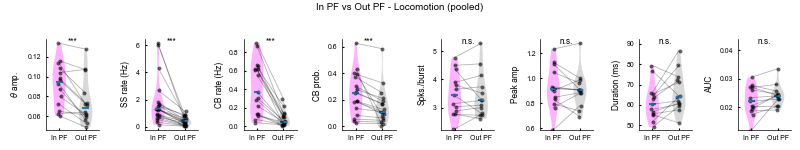

In [7]:
# Combined violin plots for Locomotion state
# Columns: theta amp | SS rate | CB rate | CB prob | Spks/burst | Peak amp | Duration | AUC

state_key = 'run'
state_label = 'Locomotion'

# Number of panels: 1 (theta) + 3 (rates) + 4 (burst metrics) = 8
n_panels = 8
panel_w = 1.0
panel_h = 1.5

fig, axes = plt.subplots(1, n_panels, figsize=(panel_w * n_panels, panel_h))

conds = [f"{state_key}_in", f"{state_key}_out"]

# Compute y limits for each metric group (only for this state)
theta_ylim = _global_ylim([theta_data['run_in'], theta_data['run_out']])

rate_ylims = {}
for metric_key in ['simple_rate', 'burst_rate', 'burst_prob']:
    all_vals = []
    for cond in ['run_in', 'run_out']:
        arr = np.asarray(rate_metrics_pooled[metric_key][cond], dtype=float)
        finite = arr[np.isfinite(arr)]
        if finite.size > 0:
            all_vals.append(finite)
    rate_ylims[metric_key] = _global_ylim(all_vals) if all_vals else None

burst_ylims = {}
for metric, _ in metric_specs_burst:
    all_vals = []
    for cond in ['run_in', 'run_out']:
        all_vals.append(np.asarray(metric_data_pooled['complex'][metric][cond], dtype=float))
    burst_ylims[metric] = _global_ylim(all_vals)

# Get masks for burst data
counts_in = np.asarray(burst_counts_pooled[conds[0]], dtype=float)
counts_out = np.asarray(burst_counts_pooled[conds[1]], dtype=float)
pair_mask_cb = ~((counts_in < min_cb_bursts_per_condition) & (counts_out < min_cb_bursts_per_condition))

counts_in_complex = np.asarray(cond_counts_pooled['complex'][conds[0]], dtype=float)
counts_out_complex = np.asarray(cond_counts_pooled['complex'][conds[1]], dtype=float)
pair_mask_complex = (
    (counts_in_complex >= min_bursts_per_condition)
    & (counts_out_complex >= min_bursts_per_condition)
)

# Compute sig_y positions (consistent height within each ylim group)
def _sig_y_from_ylim(ylim, frac=0.92):
    """Compute sig_y at a fixed fraction of the ylim range."""
    if ylim is None:
        return None
    y0, y1 = ylim
    return y0 + frac * (y1 - y0)

theta_sig_y = _sig_y_from_ylim(theta_ylim)
rate_sig_ys = {k: _sig_y_from_ylim(v) for k, v in rate_ylims.items()}
burst_sig_ys = {k: _sig_y_from_ylim(v) for k, v in burst_ylims.items()}

panel_idx = 0

# Panel 0: Theta amplitude
vals_in = np.asarray(theta_data[conds[0]], dtype=float)
vals_out = np.asarray(theta_data[conds[1]], dtype=float)
result = plot_violin_panel(axes[panel_idx], vals_in, vals_out, r'$\theta$ amp.', ylim=theta_ylim, sig_y=theta_sig_y)
if result and np.isfinite(result[0]):
    print(f"{state_label} theta amp ({result[2]}): n={result[3]}, p={result[0]:.3g}")
panel_idx += 1

# Panels 1-3: Spike/burst rates
rate_specs = [
    ('simple_rate', 'SS rate (Hz)'),
    ('burst_rate', 'CB rate (Hz)'),
    ('burst_prob', 'CB prob.'),
]
for metric_key, ylabel in rate_specs:
    vals_in_raw = np.asarray(rate_metrics_pooled[metric_key][conds[0]], dtype=float)
    vals_out_raw = np.asarray(rate_metrics_pooled[metric_key][conds[1]], dtype=float)
    if metric_key in ('burst_rate', 'burst_prob') and pair_mask_cb.size > 0:
        vals_in = vals_in_raw[pair_mask_cb]
        vals_out = vals_out_raw[pair_mask_cb]
    else:
        vals_in = vals_in_raw
        vals_out = vals_out_raw
    result = plot_violin_panel(axes[panel_idx], vals_in, vals_out, ylabel, ylim=rate_ylims[metric_key], sig_y=rate_sig_ys[metric_key])
    if result and np.isfinite(result[0]):
        print(f"{state_label} {ylabel} ({result[2]}): n={result[3]}, p={result[0]:.3g}")
    panel_idx += 1

# Panels 4-7: Burst metrics (complex only)
for metric_key, ylabel in metric_specs_burst:
    vals_in_raw = np.asarray(metric_data_pooled['complex'][metric_key][conds[0]], dtype=float)
    vals_out_raw = np.asarray(metric_data_pooled['complex'][metric_key][conds[1]], dtype=float)
    if pair_mask_complex.size > 0:
        vals_in = vals_in_raw[pair_mask_complex]
        vals_out = vals_out_raw[pair_mask_complex]
    else:
        vals_in = np.array([], dtype=float)
        vals_out = np.array([], dtype=float)
    result = plot_violin_panel(axes[panel_idx], vals_in, vals_out, ylabel, ylim=burst_ylims[metric_key], sig_y=burst_sig_ys[metric_key])
    if result and np.isfinite(result[0]):
        print(f"{state_label} {ylabel} ({result[2]}): n={result[3]}, p={result[0]:.3g}")
    panel_idx += 1

fig.suptitle(f'In PF vs Out PF - {state_label} (pooled)', fontsize=7, fontname='Arial')
plt.tight_layout(rect=[0, 0, 1, 0.92])

out_path = os.path.join(figure_save_folder, f'Combined_Violins_{state_key}_pooled.svg')
fig.savefig(out_path, dpi=300)
print(f'\nSaved to {out_path}')
plt.show()

## Combined Violin Plots - Quiet

Quiet theta amp (paired t-test): n=14, p=0.0306
Quiet SS rate (Hz) (wilcoxon): n=21, p=1.91e-06
Quiet CB rate (Hz) (paired t-test): n=20, p=0.000471
Quiet CB prob. (wilcoxon): n=20, p=0.956
Quiet Spks./burst (paired t-test): n=18, p=0.543
Quiet Peak amp (paired t-test): n=18, p=0.178
Quiet Duration (ms) (paired t-test): n=18, p=0.0156
Quiet AUC (wilcoxon): n=18, p=0.00129

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/Combined_Violins_rest_pooled.svg


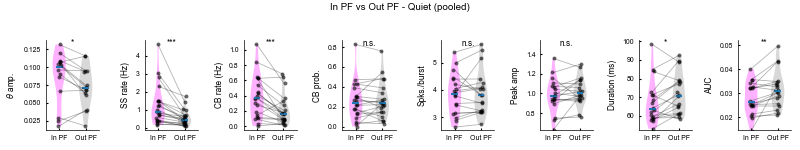

In [8]:
# Combined violin plots for Quiet state
# Columns: theta amp | SS rate | CB rate | CB prob | Spks/burst | Peak amp | Duration | AUC

state_key = 'rest'
state_label = 'Quiet'

# Number of panels: 1 (theta) + 3 (rates) + 4 (burst metrics) = 8
n_panels = 8
panel_w = 1.0
panel_h = 1.5

fig, axes = plt.subplots(1, n_panels, figsize=(panel_w * n_panels, panel_h))

conds = [f"{state_key}_in", f"{state_key}_out"]

# Compute y limits for each metric group (only for this state)
theta_ylim = _global_ylim([theta_data['rest_in'], theta_data['rest_out']])

rate_ylims = {}
for metric_key in ['simple_rate', 'burst_rate', 'burst_prob']:
    all_vals = []
    for cond in ['rest_in', 'rest_out']:
        arr = np.asarray(rate_metrics_pooled[metric_key][cond], dtype=float)
        finite = arr[np.isfinite(arr)]
        if finite.size > 0:
            all_vals.append(finite)
    rate_ylims[metric_key] = _global_ylim(all_vals) if all_vals else None

burst_ylims = {}
for metric, _ in metric_specs_burst:
    all_vals = []
    for cond in ['rest_in', 'rest_out']:
        all_vals.append(np.asarray(metric_data_pooled['complex'][metric][cond], dtype=float))
    burst_ylims[metric] = _global_ylim(all_vals)

# Get masks for burst data
counts_in = np.asarray(burst_counts_pooled[conds[0]], dtype=float)
counts_out = np.asarray(burst_counts_pooled[conds[1]], dtype=float)
pair_mask_cb = ~((counts_in < min_cb_bursts_per_condition) & (counts_out < min_cb_bursts_per_condition))

counts_in_complex = np.asarray(cond_counts_pooled['complex'][conds[0]], dtype=float)
counts_out_complex = np.asarray(cond_counts_pooled['complex'][conds[1]], dtype=float)
pair_mask_complex = (
    (counts_in_complex >= min_bursts_per_condition)
    & (counts_out_complex >= min_bursts_per_condition)
)

# Compute sig_y positions (consistent height within each ylim group)
theta_sig_y = _sig_y_from_ylim(theta_ylim)
rate_sig_ys = {k: _sig_y_from_ylim(v) for k, v in rate_ylims.items()}
burst_sig_ys = {k: _sig_y_from_ylim(v) for k, v in burst_ylims.items()}

panel_idx = 0

# Panel 0: Theta amplitude
vals_in = np.asarray(theta_data[conds[0]], dtype=float)
vals_out = np.asarray(theta_data[conds[1]], dtype=float)
result = plot_violin_panel(axes[panel_idx], vals_in, vals_out, r'$\theta$ amp.', ylim=theta_ylim, sig_y=theta_sig_y)
if result and np.isfinite(result[0]):
    print(f"{state_label} theta amp ({result[2]}): n={result[3]}, p={result[0]:.3g}")
panel_idx += 1

# Panels 1-3: Spike/burst rates
for metric_key, ylabel in rate_specs:
    vals_in_raw = np.asarray(rate_metrics_pooled[metric_key][conds[0]], dtype=float)
    vals_out_raw = np.asarray(rate_metrics_pooled[metric_key][conds[1]], dtype=float)
    if metric_key in ('burst_rate', 'burst_prob') and pair_mask_cb.size > 0:
        vals_in = vals_in_raw[pair_mask_cb]
        vals_out = vals_out_raw[pair_mask_cb]
    else:
        vals_in = vals_in_raw
        vals_out = vals_out_raw
    result = plot_violin_panel(axes[panel_idx], vals_in, vals_out, ylabel, ylim=rate_ylims[metric_key], sig_y=rate_sig_ys[metric_key])
    if result and np.isfinite(result[0]):
        print(f"{state_label} {ylabel} ({result[2]}): n={result[3]}, p={result[0]:.3g}")
    panel_idx += 1

# Panels 4-7: Burst metrics (complex only)
for metric_key, ylabel in metric_specs_burst:
    vals_in_raw = np.asarray(metric_data_pooled['complex'][metric_key][conds[0]], dtype=float)
    vals_out_raw = np.asarray(metric_data_pooled['complex'][metric_key][conds[1]], dtype=float)
    if pair_mask_complex.size > 0:
        vals_in = vals_in_raw[pair_mask_complex]
        vals_out = vals_out_raw[pair_mask_complex]
    else:
        vals_in = np.array([], dtype=float)
        vals_out = np.array([], dtype=float)
    result = plot_violin_panel(axes[panel_idx], vals_in, vals_out, ylabel, ylim=burst_ylims[metric_key], sig_y=burst_sig_ys[metric_key])
    if result and np.isfinite(result[0]):
        print(f"{state_label} {ylabel} ({result[2]}): n={result[3]}, p={result[0]:.3g}")
    panel_idx += 1

fig.suptitle(f'In PF vs Out PF - {state_label} (pooled)', fontsize=7, fontname='Arial')
plt.tight_layout(rect=[0, 0, 1, 0.92])

out_path = os.path.join(figure_save_folder, f'Combined_Violins_{state_key}_pooled.svg')
fig.savefig(out_path, dpi=300)
print(f'\nSaved to {out_path}')
plt.show()

## Summary Statistics

In [9]:
# Print summary statistics for all metrics
print('=== Summary Statistics ===')

print('\n--- Theta Amplitude ---')
for cond in conditions:
    vals = theta_data[cond]
    finite = vals[np.isfinite(vals)]
    if finite.size > 0:
        print(f'  {cond}: n={finite.size}, mean={np.mean(finite):.4f}, sem={stats.sem(finite):.4f}')

print('\n--- Spike/Burst Rates ---')
for metric_key, ylabel in rate_specs:
    print(f'  {ylabel}:')
    for cond in conditions:
        vals = np.asarray(rate_metrics_pooled[metric_key][cond], dtype=float)
        finite = vals[np.isfinite(vals)]
        if finite.size > 0:
            print(f'    {cond}: n={finite.size}, mean={np.mean(finite):.4f}, sem={stats.sem(finite):.4f}')

print('\n--- Complex Burst Metrics ---')
for metric, ylabel in metric_specs_burst:
    print(f'  {ylabel}:')
    for cond in conditions:
        vals = np.asarray(metric_data_pooled['complex'][metric][cond], dtype=float)
        finite = vals[np.isfinite(vals)]
        if finite.size > 0:
            print(f'    {cond}: n={finite.size}, mean={np.mean(finite):.4f}, sem={stats.sem(finite):.4f}')

=== Summary Statistics ===

--- Theta Amplitude ---
  run_in: n=14, mean=0.0923, sem=0.0059
  run_out: n=14, mean=0.0748, sem=0.0063
  rest_in: n=14, mean=0.0852, sem=0.0098
  rest_out: n=14, mean=0.0728, sem=0.0076

--- Spike/Burst Rates ---
  SS rate (Hz):
    run_in: n=21, mean=1.7789, sem=0.3677
    run_out: n=21, mean=0.4488, sem=0.0684
    rest_in: n=21, mean=1.2541, sem=0.2435
    rest_out: n=21, mean=0.5630, sem=0.0947
  CB rate (Hz):
    run_in: n=21, mean=0.3500, sem=0.0646
    run_out: n=21, mean=0.0658, sem=0.0171
    rest_in: n=21, mean=0.3636, sem=0.0629
    rest_out: n=21, mean=0.2063, sem=0.0446
  CB prob.:
    run_in: n=21, mean=0.2015, sem=0.0379
    run_out: n=21, mean=0.1246, sem=0.0302
    rest_in: n=21, mean=0.2460, sem=0.0425
    rest_out: n=21, mean=0.2600, sem=0.0406

--- Complex Burst Metrics ---
  Spks./burst:
    run_in: n=17, mean=3.5861, sem=0.2057
    run_out: n=13, mean=3.4417, sem=0.2225
    rest_in: n=19, mean=3.8721, sem=0.1697
    rest_out: n=19, mea